# Using Neural Networks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

# ------------------------------------------------------------
# 1. Download data (Tiny Shakespeare – classic starter dataset)
# ------------------------------------------------------------

In [2]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length: {len(text):,} characters")
print("First 300 chars:\n", text[:300])
print("-" * 60)

Dataset length: 1,115,394 characters
First 300 chars:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
------------------------------------------------------------


# ------------------------------------------------------------
# 2. Character-level (exactly what you already have)
# ------------------------------------------------------------

In [3]:
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size_char = len(chars)

print(f"Character vocab size: {vocab_size_char}")
print("Some characters:", chars[:20])

# Encode whole text as character indices
char_data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
print(f"Character sequence length: {len(char_data):,}")

Character vocab size: 65
Some characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Character sequence length: 1,115,394


# ------------------------------------------------------------
# 3. Prepare data for MLP training
# ------------------------------------------------------------

In [4]:
def create_dataset(data, seq_length):
    """Create input-output pairs for training the MLP."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.tensor(y)

seq_length = 5  # Length of the input sequence
X, y = create_dataset(char_data, seq_length)
print(f"Dataset created with {X.size(0)} samples.")
print(f"Sample input sequence (indices): {X[-5:-1]}")

Dataset created with 1115389 samples.
Sample input sequence (indices): tensor([[58,  1, 61, 39, 49],
        [ 1, 61, 39, 49, 47],
        [61, 39, 49, 47, 52],
        [39, 49, 47, 52, 45]])


# ------------------------------------------------------------
# 4. Define the MLP model
# ------------------------------------------------------------

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ------------------------------------------------------------
# 5. Train the MLP model
# ------------------------------------------------------------

In [6]:
def train_model(model, X, y, epochs=10, learning_rate=0.001, batch_size=1024):
    """Train with shuffled mini-batches: many gradient steps per epoch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    loss_history = []
    n = X.size(0)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss, steps = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X[idx], y[idx]

            # One-hot encode the input and flatten for the MLP
            one_hot_xb = F.one_hot(xb, num_classes=vocab_size_char).float().view(xb.size(0), -1)

            optimizer.zero_grad()
            output = model(one_hot_xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            steps += 1

        loss_history.append(epoch_loss / steps)
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / steps:.4f}")

    return loss_history

# ------------------------------------------------------------
# 6. Experiment with different learning rates and model sizes
# ------------------------------------------------------------

torch.Size([1, 65])
Epoch [1/5], Loss: 2.8049
Epoch [2/5], Loss: 2.1567
Epoch [3/5], Loss: 2.0337
Epoch [4/5], Loss: 1.9533
Epoch [5/5], Loss: 1.8927


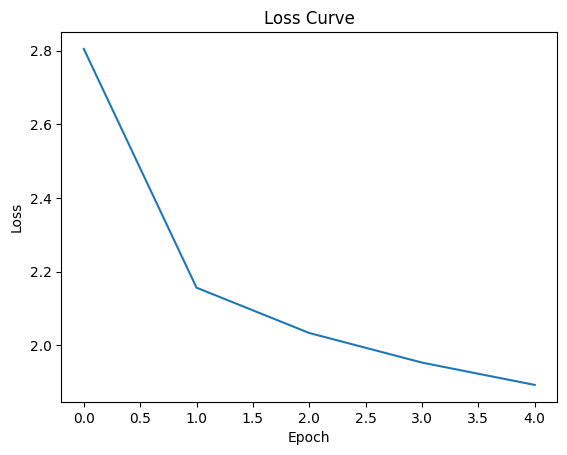

In [7]:
hidden_size = 128  # You can change this to see the effect
model = SimpleMLP(input_size=vocab_size_char * seq_length, output_size=vocab_size_char, hidden_size=128)
print(model(torch.zeros(1, vocab_size_char * seq_length)).shape)

# Train the model
loss_history = train_model(model, X, y, epochs=5, learning_rate=0.001, batch_size=4096)

# Plotting the loss curve
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ------------------------------------------------------------
# 7. Generate text using the trained MLP
# ------------------------------------------------------------

In [8]:
def generate_text(model, start_str, length=100):
    model.eval()

    if any(c not in char_to_idx for c in start_str):
        raise ValueError("start_str contains characters not present in the training data")

    generated = list(start_str)

    # Ensure the model always receives seq_length characters.
    # Pad with '\n' (line starts), not spaces: padded contexts then look
    # like real line beginnings from the training data.
    context = start_str[-seq_length:].rjust(seq_length, '\n')
    input_seq = torch.tensor(
        [[char_to_idx[c] for c in context]],
        dtype=torch.long
    )

    for _ in range(length):
        one_hot_input = F.one_hot(
            input_seq,
            num_classes=vocab_size_char
        ).float().view(1, -1)

        with torch.no_grad():
            output = model(one_hot_input)

        # Select the most likely character
        next_char_idx = torch.argmax(output, dim=1).item()
        generated.append(idx_to_char[next_char_idx])

        input_seq = torch.cat(
            (input_seq[:, 1:], torch.tensor([[next_char_idx]])),
            dim=1
        )

    return "".join(generated)

generated_text = generate_text(model, start_str="A", length=200)
print("Generated text:\n", generated_text)

Generated text:
 ARINA:
I have the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the sor the
